In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
survey = pd.read_csv("C:/Users/gcart/OneDrive/Documents/dev/r/projs/book_reviews/solve_any_data_analysis_problem_projs/CH06_asboth_Solve_Any_Data_Analysis_Problem/data/survey_results_public.csv.gz")
print(survey.shape)
survey.head()

(89184, 84)


,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


In [2]:
# what values are missing

survey.isnull().sum()

ResponseId                 0
Q120                       0
MainBranch                 0
Age                        0
Employment              1286
                       ...  
ProfessionalTech       47401
Industry               52410
SurveyLength            2699
SurveyEase              2630
ConvertedCompYearly    41165
Length: 84, dtype: int64

In [3]:
# review data dictionary

data_dict = pd.read_csv("C:/Users/gcart/OneDrive/Documents/dev/r/projs/book_reviews/solve_any_data_analysis_problem_projs/CH06_asboth_Solve_Any_Data_Analysis_Problem/data/survey_results_schema.csv")
data_dict.head(10)

,qid,qname,question,force_resp,type,selector
0,QID16,S0,"<div><span style=""font-size:19px;""><strong>Hel...",False,DB,TB
1,QID12,MetaInfo,Browser Meta Info,False,Meta,Browser
2,QID310,Q310,"<div><span style=""font-size:19px;""><strong>You...",False,DB,TB
3,QID312,Q120,,True,MC,SAVR
4,QID1,S1,"<span style=""font-size:22px; font-family: aria...",False,DB,TB
5,QID2,MainBranch,Which of the following options best describes ...,True,MC,SAVR
6,QID127,Age,What is your age? *,True,MC,MAVR
7,QID296,Employment,Which of the following best describes your cur...,False,MC,MAVR
8,QID308,RemoteWork,Which best describes your current work situation?,False,MC,SAVR
9,QID297,CodingActivities,Which of the following best describes the code...,False,MC,MAVR


In [4]:
# We will create a set of both the column names in our answer data and the values in the qname column of the data dictionary 
# dataset and see where they overlap.

len(set(survey.columns).intersection(set(data_dict["qname"])))

50

In [5]:
# we also want to know which columns don’t overlap. Subtracting two sets in Python actually gives us this difference

set(survey.columns) - set(data_dict["qname"])

{'AIDevHaveWorkedWith',
 'AIDevWantToWorkWith',
 'AINextNeither different nor similar',
 'AINextSomewhat different',
 'AINextSomewhat similar',
 'AINextVery different',
 'AINextVery similar',
 'AISearchHaveWorkedWith',
 'AISearchWantToWorkWith',
 'AIToolCurrently Using',
 'AIToolInterested in Using',
 'AIToolNot interested in Using',
 'ConvertedCompYearly',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'MiscTechHaveWorkedWith',
 'MiscTechWantToWorkWith',
 'NEWCollabToolsHaveWorkedWith',
 'NEWCollabToolsWantToWorkWith',
 'OfficeStackAsyncHaveWorkedWith',
 'OfficeStackAsyncWantToWorkWith',
 'OfficeStackSyncHaveWorkedWith',
 'OfficeStackSyncWantToWorkWith',
 'OpSysPersonal use',
 'OpSysProfessional use',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'ResponseId',
 'ToolsTechHaveWorkedWith',
 'ToolsTechWantToWorkWith',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith'}

In [6]:
# the mandatory columns according to the data dictionary.

data_dict[data_dict["force_resp"] == True]

,qid,qname,question,force_resp,type,selector
3,QID312,Q120,,True,MC,SAVR
5,QID2,MainBranch,Which of the following options best describes ...,True,MC,SAVR
6,QID127,Age,What is your age? *,True,MC,MAVR
11,QID25,EdLevel,Which of the following best describes the high...,True,MC,SAVR
22,QID6,Country,"Where do you live? <span style=""font-weight: b...",True,MC,DL
23,QID50,Currency,Which currency do you use day-to-day? If your ...,True,MC,DL
39,QID266,NEWSOSites,Which of the following Stack Overflow sites ha...,True,MC,MAVR
46,QID314,AISelect,Do you currently use AI tools in your developm...,True,MC,SAVR
54,QID299,TBranch,"<span style=""font-size:16px;"">Would you like t...",True,MC,SAVR


In [7]:
# hould have no missing data in the EdLevel column.

survey[survey["EdLevel"].isnull()]

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,71,I agree,None of these,45-54 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
304,305,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
733,734,I agree,None of these,45-54 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
875,876,I agree,None of these,45-54 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88820,88821,I agree,None of these,35-44 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88828,88829,I agree,None of these,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88830,88831,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89028,89029,I agree,None of these,45-54 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# how many missing columns there are for each participant that has a missing value for the EdLevel column

survey[survey["EdLevel"].isnull()].isnull().sum(axis=1).sort_values()

0        80
65302    80
65252    80
65037    80
64859    80
         ..
43794    80
43573    80
43567    80
43519    80
89159    80
Length: 1211, dtype: int64

In [9]:
# anywhere with all survey answer columns missing can be dropped

survey.isnull().sum().loc[lambda x: x==0]

ResponseId    0
Q120          0
MainBranch    0
Age           0
dtype: int64

In [10]:
# Are there the same number of missing values when Currency is missing?

survey[survey["Currency"].isnull()].isnull().sum(axis=1)

0        80
9        33
35       51
46       42
47       52
         ..
89173    16
89176    37
89180    33
89181    54
89182    30
Length: 23850, dtype: int64

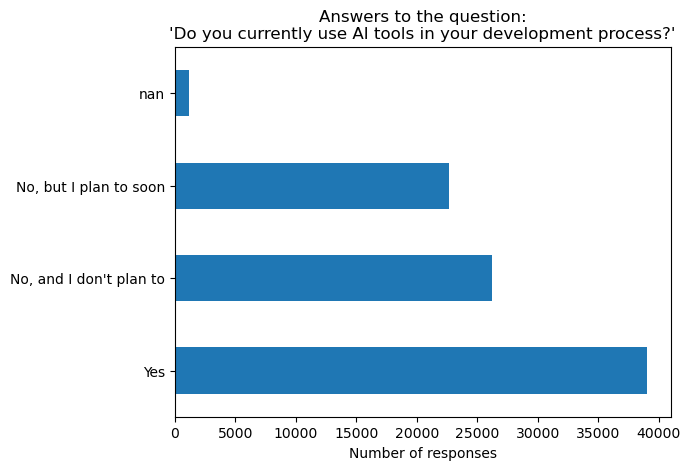

In [12]:
# we should understand what proportion of people are even using AI tools

fig, axis = plt.subplots()
 
(
    survey["AISelect"]
    .value_counts(dropna=False)
    .plot
    .barh(ax=axis)
)
 
axis.set(title="Answers to the question:\n'Do you currently use AI tools in your development process?'",
         xlabel="Number of responses")
 
plt.show()

In [13]:
# look at the distribution of the AISent column to see how people answered

survey["AISent"].value_counts(dropna=False)

Favorable           29863
NaN                 27683
Very favorable      17050
Indifferent         10147
Unsure               2471
Unfavorable          1698
Very unfavorable      272
Name: AISent, dtype: int64

In [14]:
# there are lots of missing answers, so we can fill this value in with a placeholder, such as “no answer given.
# make the data type of this column explicitly categorical to set the ordering of the values so that whenever 
# they appear in a data table or a chart, they are not ordered alphabetically. We do all this using the pandas 
# Categorical data type.

survey["AISent"] = (
    pd.Categorical(
        survey["AISent"].fillna("No answer given"),
        categories=['No answer given', 'Unsure',
                    'Very unfavorable', 'Unfavorable',
                    'Indifferent', 'Favorable', 'Very favorable'],
        ordered=True)
)
 
survey["AISent"].value_counts(dropna=False).sort_index()

No answer given     27683
Unsure               2471
Very unfavorable      272
Unfavorable          1698
Indifferent         10147
Favorable           29863
Very favorable      17050
Name: AISent, dtype: int64

In [15]:
# compare the distribution of these answers across the groups of AI tool users, non-users, and aspiring users.

pd.crosstab(
    index=survey["AISelect"],
    columns=survey["AISent"]
)

AISent,No answer given,Unsure,Very unfavorable,Unfavorable,Indifferent,Favorable,Very favorable
AISelect,,,,,,,
"No, and I don't plan to",26221,0,0,0,0,0,0
"No, but I plan to soon",155,1762,129,927,5858,10790,3089
Yes,96,709,143,771,4289,19073,13961


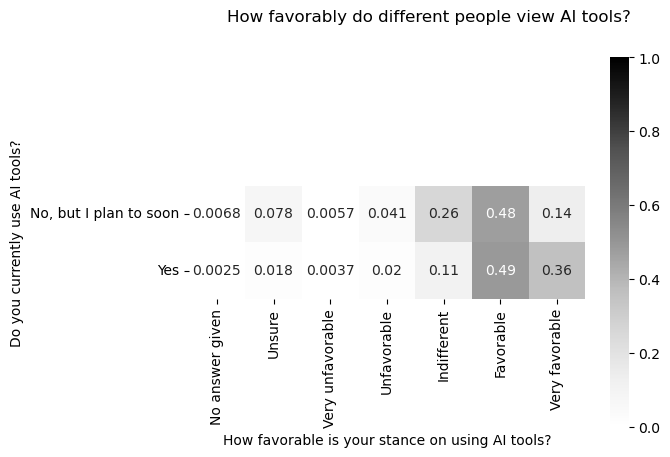

In [16]:
fig, axis = plt.subplots()
 
sns.heatmap(
    data=pd.crosstab(
        index  =survey.loc[survey["AISelect"] != "No, and I don't plan to", "AISelect"],
        columns=survey.loc[survey["AISelect"] != "No, and I don't plan to", "AISent"],
        normalize="index"
    ),
    cmap="Greys",
    vmin=0,
    vmax=1,
    square=True,
    annot=True,
    ax=axis
)
 
fig.suptitle("How favorably do different people view AI tools?")
 
axis.set(
    xlabel="How favorable is your stance on using AI tools?",
    ylabel="Do you currently use AI tools?"
)
 
plt.show()

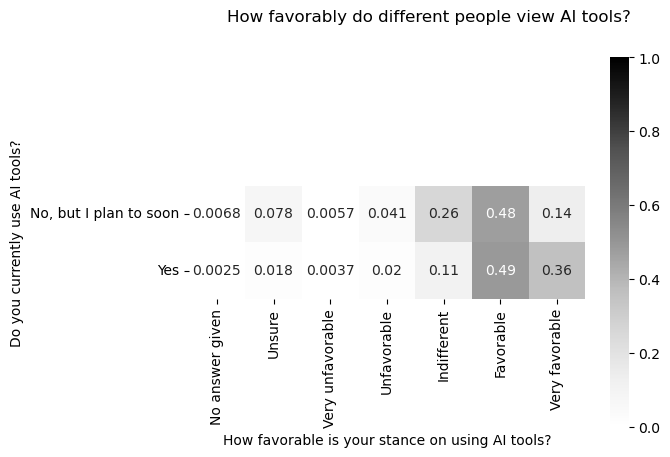

In [17]:
# We will reuse this create_heatmap method throughout the solution.

def create_heatmap(data, square=True):
    fig, axis = plt.subplots()
 
    sns.heatmap(
        data=data,
        cmap="Greys",
        vmin=0,
        vmax=1,
        square=square,
        annot=True,
        ax=axis
    )
 
    return fig, axis
 
fig, axis = create_heatmap(
    pd.crosstab(
        index=survey.loc[survey["AISelect"] != "No, and I don't plan to", "AISelect"],
        columns=survey.loc[survey["AISelect"] != "No, and I don't plan to", "AISent"],
        normalize="index"
    )
)
 
fig.suptitle("How favorably do different people view AI tools?")
 
axis.set(
    xlabel="How favorable is your stance on using AI tools?",
    ylabel="Do you currently use AI tools?"
)
 
plt.show()

In [18]:
# The AIBen column also has missing data, so we chose to fill these in and create an ordered Categorical column again

survey["AIBen"] = (
    pd.Categorical(
        survey["AIBen"].fillna("No answer given"),
        categories=['No answer given', 'Highly distrust',
                    'Somewhat distrust', 'Neither trust nor distrust',
                    'Somewhat trust', 'Highly trust'],
        ordered=True
    )
)
 
survey["AIBen"].value_counts(dropna=False).sort_index()

No answer given               27788
Highly distrust                3350
Somewhat distrust             13330
Neither trust nor distrust    18837
Somewhat trust                24128
Highly trust                   1751
Name: AIBen, dtype: int64

In [19]:
# comparing these answers across AI users and aspiring users 

pd.crosstab(
    index=survey["AISelect"],
    columns=survey["AIBen"]
)

AIBen,No answer given,Highly distrust,Somewhat distrust,Neither trust nor distrust,Somewhat trust,Highly trust
AISelect,,,,,,
"No, and I don't plan to",26221,0,0,0,0,0
"No, but I plan to soon",202,1303,5975,8085,6764,381
Yes,154,2047,7355,10752,17364,1370


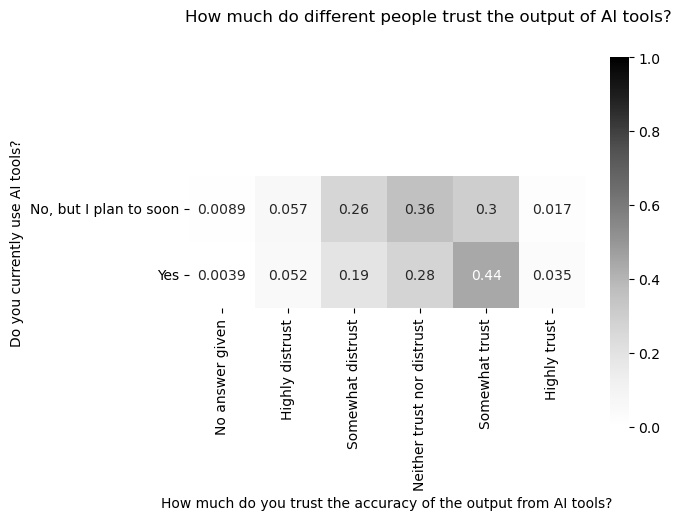

In [20]:
# exclude non-users and generate a heatmap of the crosstab.

fig, axis = create_heatmap(
    pd.crosstab(
        index=survey.loc[survey["AISelect"]   != "No, and I don't plan to", "AISelect"],
        columns=survey.loc[survey["AISelect"] != "No, and I don't plan to", "AIBen"],
        normalize="index"
    )
)
 
fig.suptitle("How much do different people trust the output of AI tools?")
 
axis.set(
  xlabel="How much do you trust the accuracy of the output from AI tools?",
  ylabel="Do you currently use AI tools?"
)
 
plt.show()

In [21]:
(
    survey.loc[survey["AISelect"] == "Yes", "AIToolCurrently Using"]
    .dropna()
    .head(10)
)

1            Writing code;Committing and reviewing code
4     Learning about a codebase;Writing code;Documen...
5               Writing code;Debugging and getting help
6               Writing code;Debugging and getting help
7     Project planning;Writing code;Debugging and ge...
9               Writing code;Debugging and getting help
11                            Writing code;Testing code
13              Writing code;Debugging and getting help
15                                         Writing code
16                                         Writing code
Name: AIToolCurrently Using, dtype: object

In [22]:
# generates the indicator columns

ai_tool_indicators = (
    survey.loc[survey["AISelect"] == "Yes", "AIToolCurrently Using"]
    .str.get_dummies(sep=";")
)
ai_tool_indicators

,Collaborating with teammates,Committing and reviewing code,Debugging and getting help,Deployment and monitoring,Documenting code,Learning about a codebase,Other (please describe),Project planning,Testing code,Writing code
1,0,1,0,0,0,0,0,0,0,1
4,0,0,1,0,1,1,0,0,0,1
5,0,0,1,0,0,0,0,0,0,1
6,0,0,1,0,0,0,0,0,0,1
7,0,0,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
89176,0,0,0,0,1,1,0,1,0,1
89179,0,0,1,0,1,0,0,0,0,1
89180,0,0,1,0,0,1,0,0,0,0
89182,0,0,1,1,0,1,0,0,0,1


In [23]:
# xperience might tell us that when separating delimited strings, we could end up with trailing spaces in column names, so let’s check 
# and fix that.

ai_tool_indicators.columns = [c.strip() for c in ai_tool_indicators.columns]

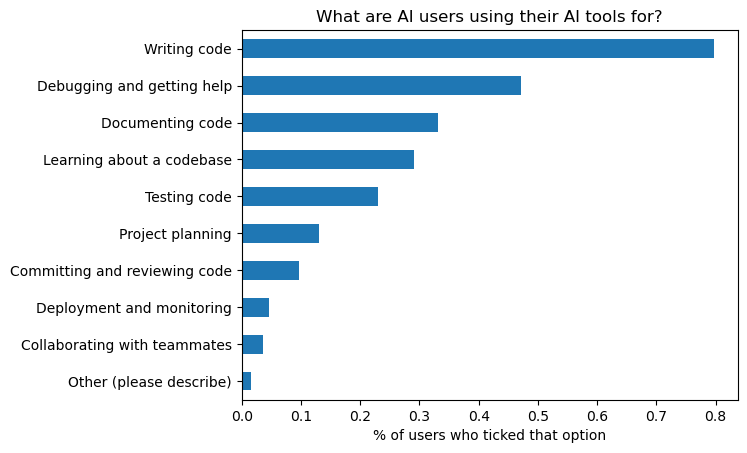

In [24]:
# what percent of participants checked each option

fig, axis = plt.subplots()
 
(
    ai_tool_indicators
    .mean()
    .sort_values()
    .plot
    .barh(ax=axis)
)
 
axis.set(
    title="What are AI users using their AI tools for?",
    xlabel="% of users who ticked that option"
)
 
plt.show()

In [25]:
# dd the indicator columns to our original data and keep a filtered dataset of only AI users for use in the
# remaining investigations.

# concat will by default match on indices
survey_ai_users = (
    pd.concat([survey, ai_tool_indicators], axis=1)
    .dropna(subset=ai_tool_indicators.columns, how="any") # drop nulls
)
 
assert len(survey[survey["AISelect"] == "Yes"]) == len(survey_ai_users)
 
survey_ai_users.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Collaborating with teammates,Committing and reviewing code,Debugging and getting help,Deployment and monitoring,Documenting code,Learning about a codebase,Other (please describe),Project planning,Testing code,Writing code
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
5,6,I agree,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;Colleague;Online Course...,Formal documentation provided by the owner of ...,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,7,I agree,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Profe...,Some college/university study without earning ...,Friend or family member;Online Courses or Cert...,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,8,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [26]:
# create a long-form version of one of the multiple-choice options cross-referenced against favorability

(
    survey_ai_users[survey_ai_users["Collaborating with teammates"] == 1]
    .groupby("AISent")
    .size()
    .reset_index(name="count")
    .assign(option="Collaborating with teammates")
)

,AISent,count,option
0,No answer given,0,Collaborating with teammates
1,Unsure,19,Collaborating with teammates
2,Very unfavorable,10,Collaborating with teammates
3,Unfavorable,12,Collaborating with teammates
4,Indifferent,99,Collaborating with teammates
5,Favorable,534,Collaborating with teammates
6,Very favorable,703,Collaborating with teammates


In [27]:
tool_favorability_dfs = []
for col in ai_tool_indicators.columns:
    option_df = (
        survey_ai_users[survey_ai_users[col] == 1]
        .groupby("AISent")
        .size()
        .reset_index(name="count")
        .assign(option=col)
    )
    tool_favorability_dfs.append(option_df)
 
options_vs_favorability = pd.concat(
    tool_favorability_dfs,
    axis=0,
    ignore_index=True
)
 
print(options_vs_favorability.shape)

(70, 3)


In [28]:
#  create a crosstab of percentages

favorability_crosstab = (
    pd.crosstab(index=options_vs_favorability["option"],
                columns=options_vs_favorability["AISent"],
                values=options_vs_favorability["count"],
                aggfunc="sum",
                normalize="index")
)
favorability_crosstab

AISent,No answer given,Unsure,Very unfavorable,Unfavorable,Indifferent,Favorable,Very favorable
option,,,,,,,
Collaborating with teammates,0.000000,0.013798,0.007262,0.008715,0.071895,0.387800,0.510530
Committing and reviewing code,0.000788,0.011298,0.003678,0.008408,0.068050,0.392801,0.514976
Debugging and getting help,0.000651,0.014156,0.002658,0.013614,0.077019,0.464555,0.427347
Deployment and monitoring,0.001119,0.013423,0.006711,0.009508,0.064318,0.381991,0.522931
Documenting code,0.000386,0.011417,0.002314,0.010723,0.076294,0.446810,0.452056
Learning about a codebase,0.000441,0.014009,0.003348,0.012335,0.078767,0.441322,0.449780
Other (please describe),0.000000,0.034542,0.010363,0.044905,0.143351,0.436960,0.329879
Project planning,0.000785,0.012753,0.003335,0.010202,0.066706,0.404159,0.502060
Testing code,0.000556,0.011889,0.003444,0.010556,0.067778,0.433222,0.472556


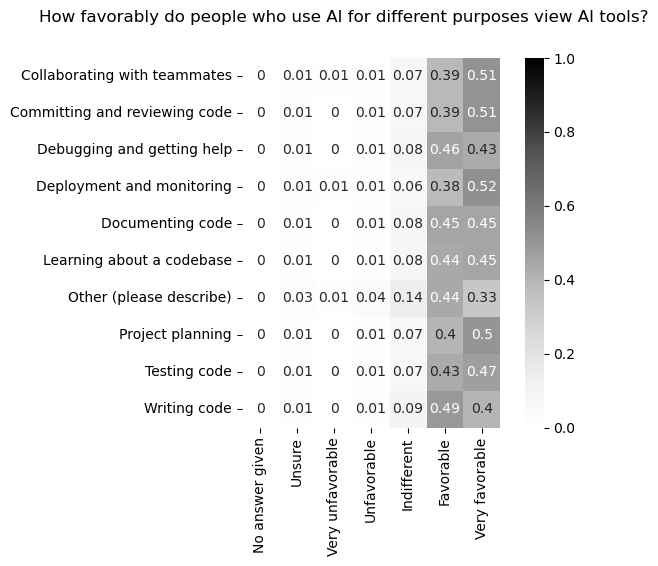

In [29]:
# generate a heatmap

fig, axis = create_heatmap(
    favorability_crosstab.round(2)
)
 
fig.suptitle("How favorably do people who use AI for different purposes view AI tools?")
 
axis.set(xlabel=None, ylabel=None)
 
plt.show()

In [30]:
# repeat this latest crosstab and heatmap process for the AIBen column as well

tool_trust_dfs = []
for col in ai_tool_indicators.columns:
    option_df = (
        survey_ai_users[survey_ai_users[col] == 1]
        .groupby("AIBen")
        .size()
        .reset_index(name="count")
        .assign(option=col)
    )
    tool_trust_dfs.append(option_df)
 
options_vs_trust = pd.concat(tool_trust_dfs, axis=0, ignore_index=True)
 
print(options_vs_trust.shape)
options_vs_trust.head()

(60, 3)


,AIBen,count,option
0,No answer given,2,Collaborating with teammates
1,Highly distrust,43,Collaborating with teammates
2,Somewhat distrust,143,Collaborating with teammates
3,Neither trust nor distrust,317,Collaborating with teammates
4,Somewhat trust,705,Collaborating with teammates


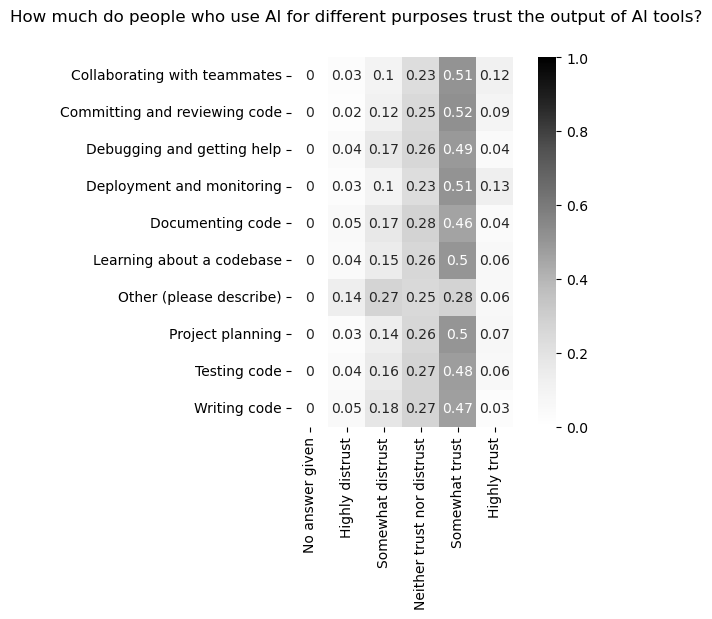

In [32]:
# create the crosstab and heatmap

trust_crosstab = (
    pd.crosstab(index=options_vs_trust["option"],
                columns=options_vs_trust["AIBen"],
                values=options_vs_trust["count"],
                aggfunc="sum",
                normalize="index")
)
 
fig, axis = create_heatmap(
    trust_crosstab.round(2)
)
 
fig.suptitle("How much do people who use AI for different purposes trust the output of AI tools?")
 
axis.set(xlabel=None, ylabel=None)
 
plt.show()

In [33]:
# look at the distribution of values in the DevType column, but only for people who are using AI tools

survey_ai_users['DevType'].value_counts(dropna=False)

Developer, full-stack                            12316
NaN                                               5509
Developer, back-end                               5499
Developer, front-end                              2622
Other (please specify):                           1221
Developer, mobile                                 1126
Student                                           1106
Developer, desktop or enterprise applications     1087
Data scientist or machine learning specialist      953
Engineering manager                                823
Senior Executive (C-Suite, VP, etc.)               681
DevOps specialist                                  600
Academic researcher                                571
Engineer, data                                     534
Research & Development role                        500
Developer, embedded applications or devices        486
Cloud infrastructure engineer                      467
Data or business analyst                           349
Developer,

In [34]:
# Let’s see which of these groups could go into our larger “developer” group

devtypes = (
    survey_ai_users
    .dropna(subset=["DevType"])
    .query("DevType.str.startswith('Developer')")
    .loc[:,"DevType"]
)
 
devtypes.value_counts()

Developer, full-stack                            12316
Developer, back-end                               5499
Developer, front-end                              2622
Developer, mobile                                 1126
Developer, desktop or enterprise applications     1087
Developer, embedded applications or devices        486
Developer, game or graphics                        326
Developer, QA or test                              231
Developer Experience                               139
Developer Advocate                                  98
Name: DevType, dtype: int64

In [35]:
# create a dictionary that matches each of these roles with the “new” category they should belong to

devtype_map = {}
 
dev_exclusions = ["Developer Experience", "Developer Advocate"]
 
dev_devtypes = [col for col in devtypes.value_counts().index if col not in dev_exclusions]
 
for col in dev_devtypes:
    devtype_map[col] = "Developer"

In [36]:
# a few engineering roles that could be grouped together, so let’s also do that.

eng_devtypes = (
    survey_ai_users
    .dropna(subset=["DevType"])
    .query("DevType.str.contains('engineer', case=False)")
    .loc[:,"DevType"]
)
 
eng_devtypes.value_counts()

Engineering manager              823
Engineer, data                   534
Cloud infrastructure engineer    467
Engineer, site reliability       160
Hardware Engineer                 80
Name: DevType, dtype: int64

In [37]:
# All of these roles can go under one “engineer” category for now, except the management one.

for col in ['Engineer, data', 'Cloud infrastructure engineer',
            'Engineer, site reliability', 'Hardware Engineer']:
    devtype_map[col] = "Engineer"
 
survey_ai_users["job_category"] = survey_ai_users["DevType"].replace(devtype_map)
 
survey_ai_users["job_category"].value_counts(dropna=False)

Developer                                        23693
NaN                                               5509
Engineer                                          1241
Other (please specify):                           1221
Student                                           1106
Data scientist or machine learning specialist      953
Engineering manager                                823
Senior Executive (C-Suite, VP, etc.)               681
DevOps specialist                                  600
Academic researcher                                571
Research & Development role                        500
Data or business analyst                           349
System administrator                               257
Project manager                                    232
Blockchain                                         200
Product manager                                    183
Educator                                           174
Security professional                              171
Developer 

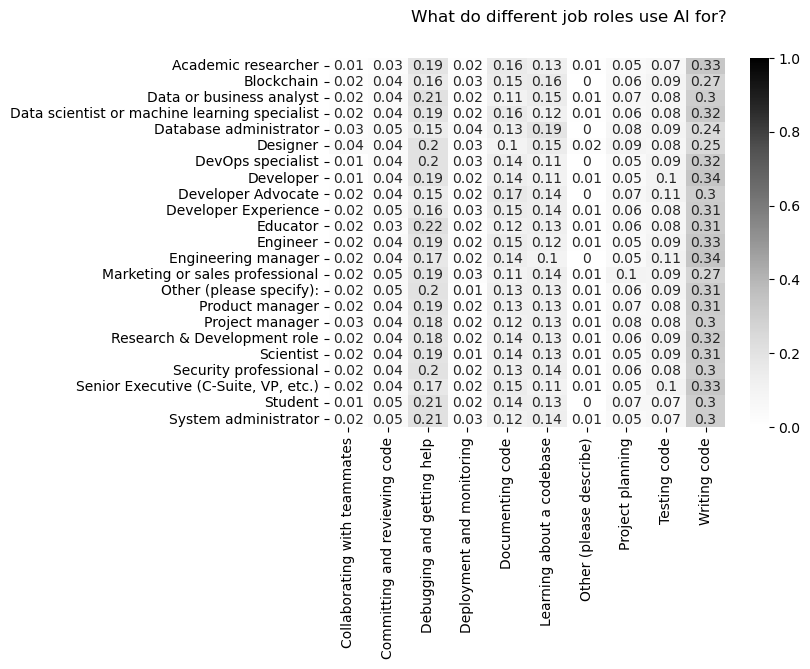

In [38]:
# cross-reference job roles with AI use cases

tool_job_dfs = []
 
for col in ai_tool_indicators.columns:
    option_df = (
        survey_ai_users[survey_ai_users[col] == 1]
        .dropna(subset="job_category")
        .groupby("job_category")
        .size()
        .reset_index(name="count")
        .assign(option=col)
    )
    tool_job_dfs.append(option_df)
 
options_vs_jobs = pd.concat(tool_job_dfs, axis=0, ignore_index=True)
 
job_crosstab = (
    pd.crosstab(index=options_vs_jobs["option"],
                columns=options_vs_jobs["job_category"],
                values=options_vs_jobs["count"],
                aggfunc="sum",
                normalize="columns")
    .transpose()
)
 
fig, axis = create_heatmap(
    job_crosstab.round(2),
    square=False
)
 
fig.suptitle("What do different job roles use AI for?")
 
axis.set(xlabel=None, ylabel=None)
 
plt.show()

In [40]:
# Let’s see the values in our YearsCodePro column

survey_ai_users["YearsCodePro"].unique()

array(['9', '4', '21', '3', '15', nan, 'Less than 1 year', '10', '2', '6',
       '14', '7', '5', '16', '20', '11', '12', '19', '8', '50', '27',
       '13', '1', '18', '44', '22', '25', '24', '17', '26', '37', '30',
       'More than 50 years', '23', '32', '39', '28', '35', '36', '33',
       '34', '41', '31', '40', '38', '29', '43', '42', '45', '48', '47',
       '49', '46'], dtype=object)

In [41]:
survey_ai_users["YearsCodePro"] = (
    survey_ai_users["YearsCodePro"]
    .replace({
        'Less than 1 year': 0,
        'More than 50 years': 50
    })
    .astype(float) # to account for NULLs
)

<AxesSubplot:>

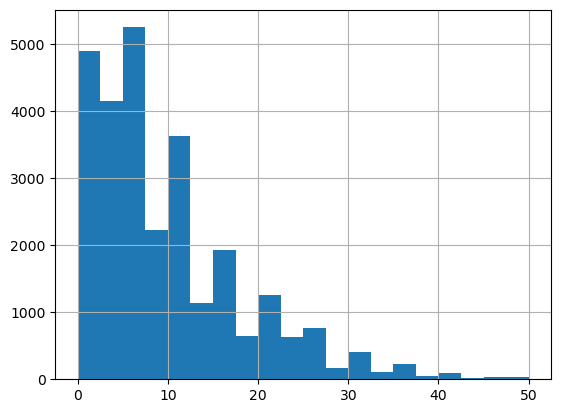

In [42]:
# let’s see its distribution

survey_ai_users["YearsCodePro"].hist(bins=20)

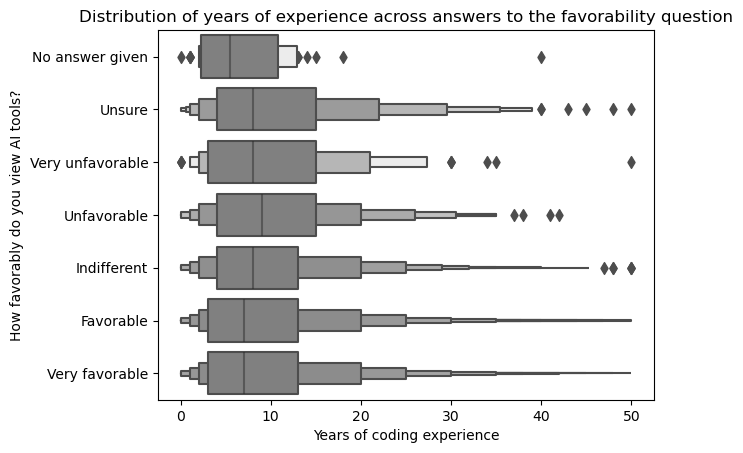

In [44]:
# Let us look at an example using something the Python library seaborn calls “boxenplots”, which are similar to box-and-whisker 
# plots but with more information

fig, axis = plt.subplots()
 
sns.boxenplot(
    data=survey_ai_users,
    x="YearsCodePro", y="AISent",
    color="gray",
    ax=axis
)
 
axis.set(
    title="Distribution of years of experience across answers to the favorability question",
    xlabel="Years of coding experience",
    ylabel="How favorably do you view AI tools?"
)
 
plt.show()

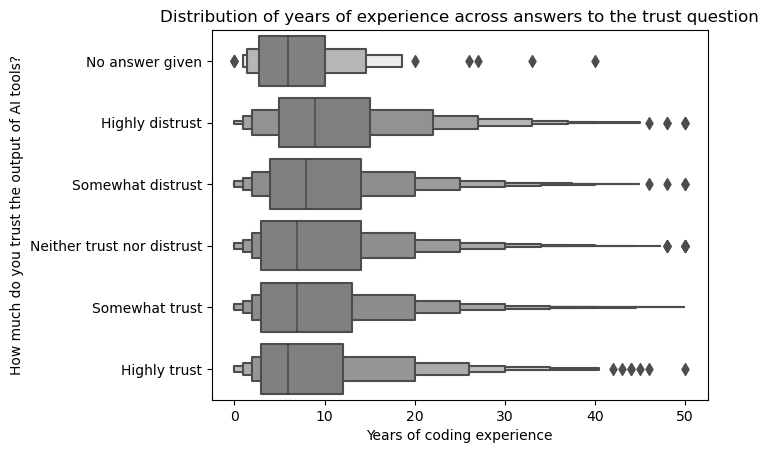

In [46]:
# how much different experience levels trust the output of AI tools.

fig, axis = plt.subplots()
 
sns.boxenplot(
    data=survey_ai_users,
    x="YearsCodePro", y="AIBen",
    color="gray",
    ax=axis
)
 
axis.set(
    title="Distribution of years of experience across answers to the trust question",
    xlabel="Years of coding experience",
    ylabel="How much do you trust the output of AI tools?"
)
 
plt.show()

In [47]:
# we need another crosstab-to-heatmap process, this time comparing years of experience and answers to the favorability 
# and trust questions.

exp_bins = pd.cut(survey_ai_users["YearsCodePro"],
                  bins=[-1, 0, 2, 5, 10, 20, 50],
                  labels=["0", "1-2 years", "3-5 years",
                          "6-10 years", "11-20 years",
                          "over 20 years"]
                 )
 
# verify the groups
survey_ai_users.groupby(exp_bins)["YearsCodePro"].agg(["min", "max"])

,min,max
YearsCodePro,,
0,0.0,0.0
1-2 years,1.0,2.0
3-5 years,3.0,5.0
6-10 years,6.0,10.0
11-20 years,11.0,20.0
over 20 years,21.0,50.0


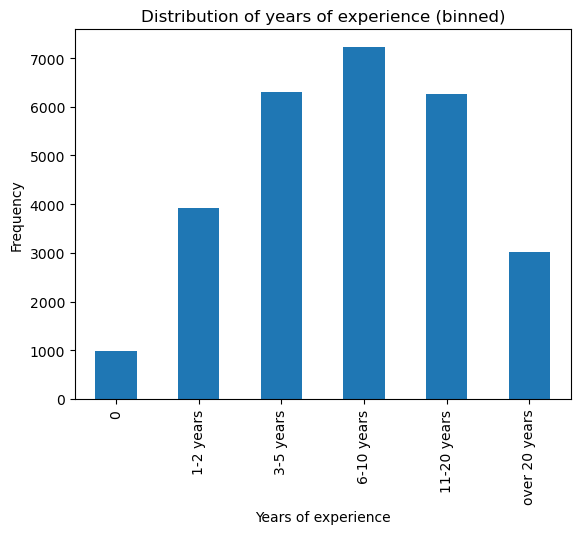

In [48]:
# Now that our experience column is categorical, we can look at its distribution

fig, axis = plt.subplots()
 
(
    exp_bins
    .value_counts()
    .sort_index()
    .plot
    .bar(ax=axis)
)
 
axis.set(
    title="Distribution of years of experience (binned)",
    xlabel="Years of experience",
    ylabel="Frequency"
)
 
plt.show()

In [49]:
exp_vs_sent = pd.crosstab(
    index=exp_bins,
    columns=survey_ai_users["AISent"],
    normalize="index"
)
 
exp_vs_sent

AISent,No answer given,Unsure,Very unfavorable,Unfavorable,Indifferent,Favorable,Very favorable
YearsCodePro,,,,,,,
0,0.001011,0.015167,0.004044,0.018200,0.104146,0.505561,0.351871
1-2 years,0.002552,0.017096,0.004083,0.015310,0.101046,0.510079,0.349834
3-5 years,0.001587,0.014596,0.001745,0.015865,0.104871,0.488974,0.372362
6-10 years,0.001384,0.016602,0.004289,0.019231,0.112618,0.476065,0.369812
11-20 years,0.001599,0.017426,0.003197,0.023341,0.112390,0.483933,0.358114
over 20 years,0.000332,0.021920,0.004318,0.020923,0.107938,0.474925,0.369645


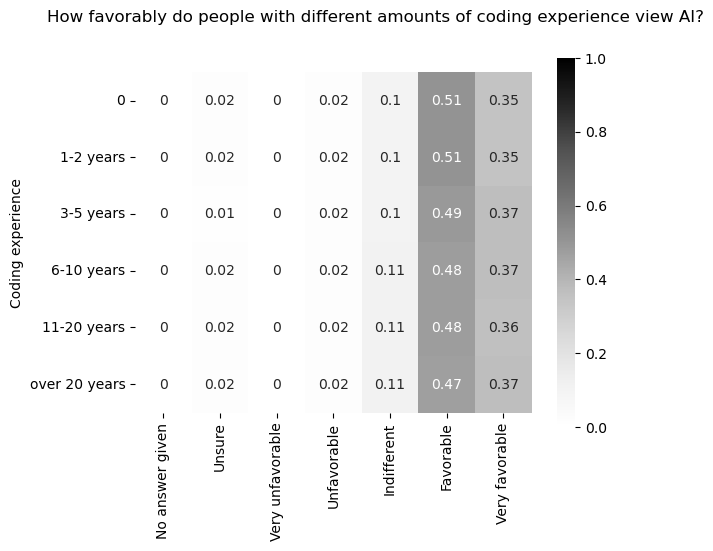

In [51]:
fig, axis = create_heatmap(
    exp_vs_sent.round(2)
)
 
fig.suptitle("How favorably do people with different amounts of coding experience view AI?")
 
axis.set(
    xlabel=None,
    ylabel="Coding experience"
)
 
plt.show()

In [52]:
# What about trust in AI tools? 

fig, axis = create_heatmap(
    exp_vs_trust.round(2)
)
 
fig.suptitle("How much do people with different amounts of coding experience trust the output of an AI?")
 
axis.set(
    xlabel=None,
    ylabel="Coding experience"
)
 
plt.show()

NameError: name 'exp_vs_trust' is not defined

In [53]:
trust_exp_data = (
    survey_ai_users
    .dropna(subset=["YearsCodePro", "AIBen"], how="any")
    .loc[survey_ai_users["AIBen"] != "No answer given", :]
)
 
trust_rank = (
    pd.Series(
        trust_exp_data["AIBen"]
        .factorize(sort=True)[0]
    )
    .rank()
)
 
from scipy.stats import spearmanr, kendalltau
 
correlation, p_value = spearmanr(
    trust_exp_data["YearsCodePro"],
    trust_rank
)
 
print("Spearman's\n", correlation, p_value)
 
correlation, p_value = kendalltau(
    trust_exp_data["YearsCodePro"],
    trust_rank
)
 
print("Kendall's tau\n", correlation, p_value)

Spearman's
 -0.0650445414009189 2.6886332522054823e-27
Kendall's tau
 -0.05052236119624125 2.5557806077186822e-27


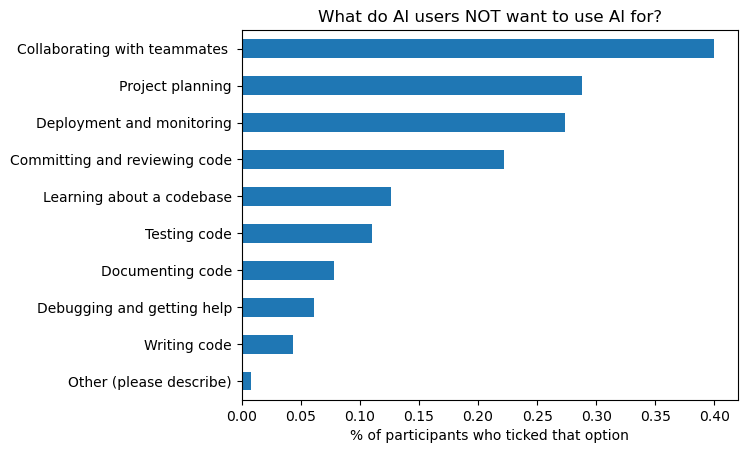

In [54]:
ai_not_interested_indicators = (
  survey.loc[survey["AISelect"] == "Yes", "AIToolNot interested in Using"]
  .str.get_dummies(sep=";")
)
 
fig, axis = plt.subplots()
 
(
    ai_not_interested_indicators
    .mean()
    .sort_values()
    .plot
    .barh(ax=axis)
)
 
axis.set(
    title="What do AI users NOT want to use AI for?",
    xlabel="% of participants who ticked that option"
)
 
plt.show()

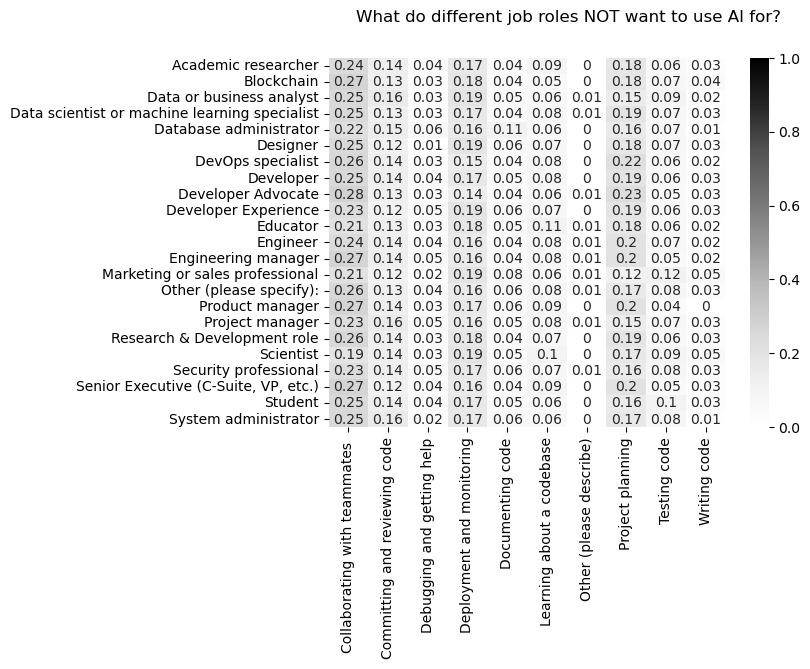

In [55]:
ai_users_not_int = (
    pd.concat([survey, ai_not_interested_indicators], axis=1)
    .dropna(subset=ai_not_interested_indicators.columns, how="any")
)
 
ai_users_not_int["job_category"] = ai_users_not_int["DevType"].replace(devtype_map)
 
not_interested_job_dfs = []
 
for col in ai_not_interested_indicators.columns:
    option_df = (
        ai_users_not_int[ai_users_not_int[col] == 1]
        .dropna(subset="job_category")
        .groupby("job_category")
        .size()
        .reset_index(name="count")
        .assign(option=col)
    )
    not_interested_job_dfs.append(option_df)
 
not_interested_options_vs_jobs = pd.concat(not_interested_job_dfs, axis=0, ignore_index=True)
 
job_not_int_crosstab = (
    pd.crosstab(index=not_interested_options_vs_jobs["option"],
                columns=not_interested_options_vs_jobs["job_category"],
                values=not_interested_options_vs_jobs["count"],
                aggfunc="sum",
                normalize="columns")
    .transpose()
)
 
fig, axis = create_heatmap(
    job_not_int_crosstab.round(2),
    square=False
)
 
fig.suptitle("What do different job roles NOT want to use AI for?")
 
axis.set(xlabel=None, ylabel=None)
 
plt.show()